In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [4]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [13]:
print(df.shape[0])

299


In [12]:
print(df.shape[1])

13


In [14]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [15]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop_duplicates(inplace=True)

In [20]:
df.shape

(299, 13)

In [21]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

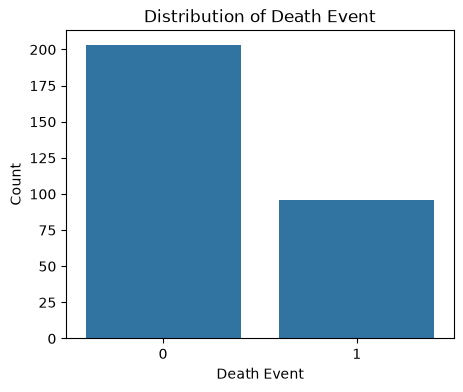

In [22]:
plt.figure(figsize=(5,4))

sns.countplot(x="DEATH_EVENT", data=df)

plt.title("Distribution of Death Event")
plt.xlabel("Death Event")
plt.ylabel("Count")

plt.show()

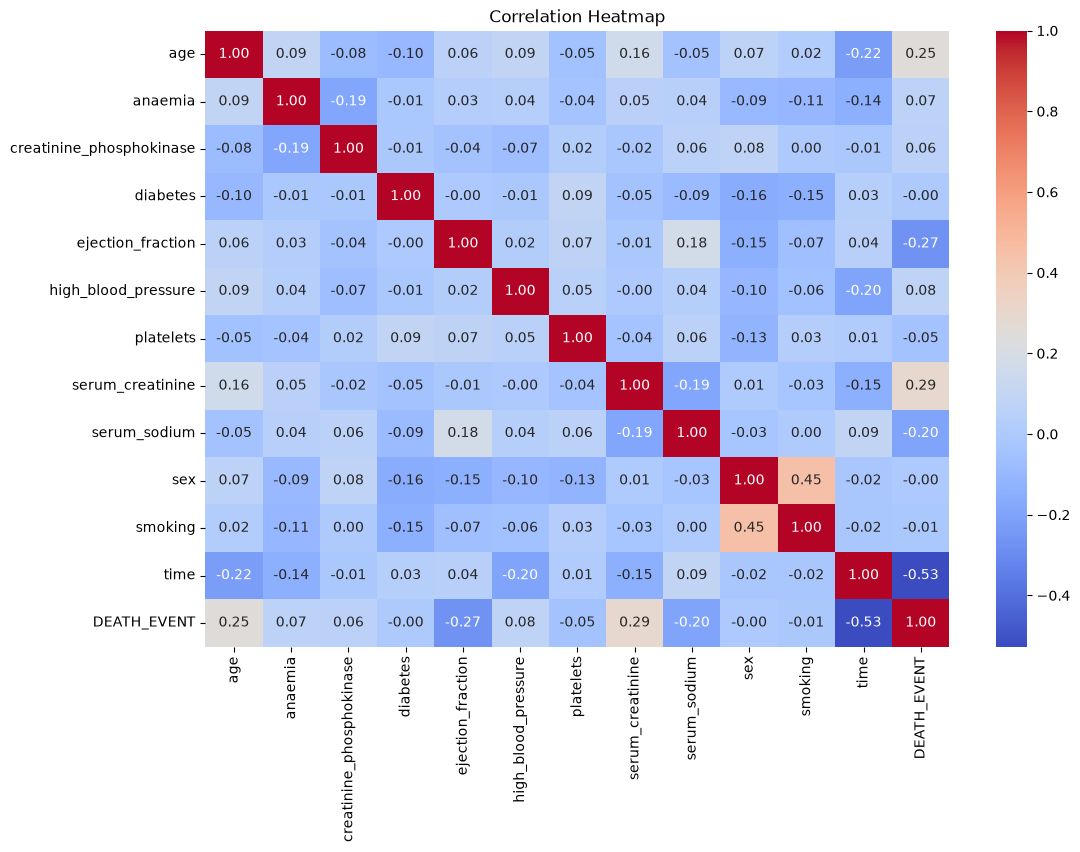

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

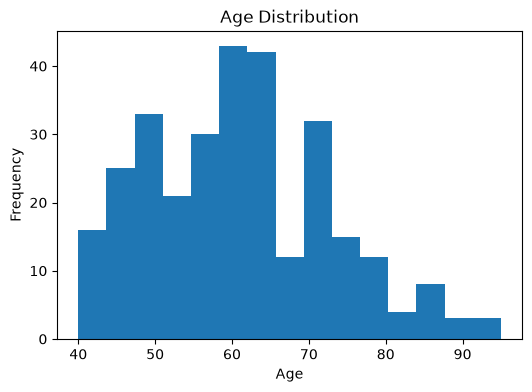

In [24]:
plt.figure(figsize=(6,4))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

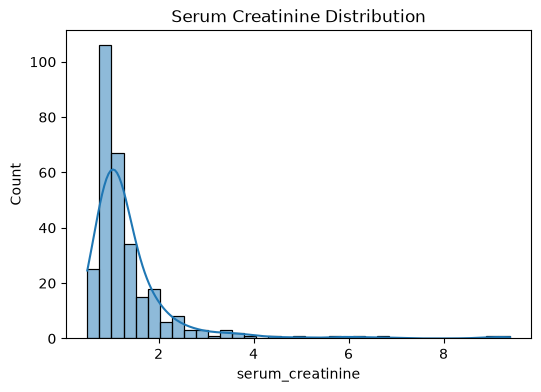

In [25]:
plt.figure(figsize=(6,4))

sns.histplot(df["serum_creatinine"], kde=True)

plt.title("Serum Creatinine Distribution")

plt.show()

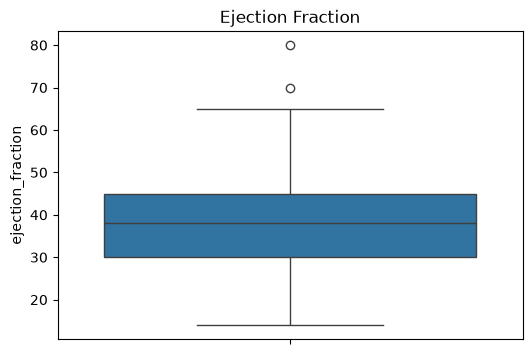

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["ejection_fraction"])

plt.title("Ejection Fraction")

plt.show()

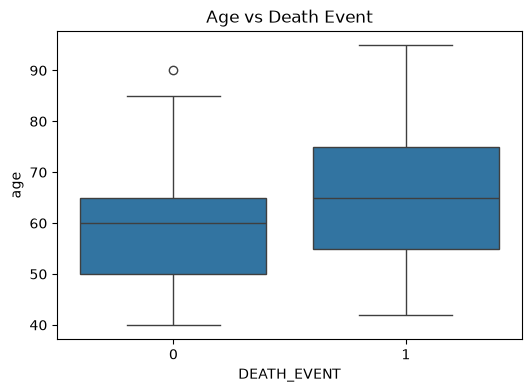

In [27]:
plt.figure(figsize=(6,4))

sns.boxplot(x="DEATH_EVENT", y="age", data=df)

plt.title("Age vs Death Event")

plt.show()

In [28]:
X = df.drop("DEATH_EVENT", axis=1)

y = df["DEATH_EVENT"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (299, 12)
Target Shape: (299,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (239, 12)
Testing Data: (60, 12)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
log_pred = log_model.predict(X_test)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, log_pred))

print("\nClassification Report\n")
print(classification_report(y_test, log_pred))

Accuracy : 0.8166666666666667
Precision: 0.7857142857142857
Recall   : 0.5789473684210527
F1 Score : 0.6666666666666666

Confusion Matrix

[[38  3]
 [ 8 11]]

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



In [35]:
from sklearn.tree import DecisionTreeClassifier


In [36]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
dt_pred = dt_model.predict(X_test)

In [38]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.7333333333333333
Precision: 0.6
Recall   : 0.47368421052631576
F1 Score : 0.5294117647058824


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rf_pred = rf_model.predict(X_test)

In [42]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.8333333333333334
Precision: 0.8
Recall   : 0.631578947368421
F1 Score : 0.7058823529411765


In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [45]:
knn_pred = knn_model.predict(X_test)

In [46]:
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))

Accuracy : 0.7
Precision: 0.5714285714285714
Recall   : 0.21052631578947367
F1 Score : 0.3076923076923077


In [47]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, knn_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, knn_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, knn_pred)
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.833333,0.800000,0.631579,0.705882
0,Logistic Regression,0.816667,0.785714,0.578947,0.666667
1,Decision Tree,0.733333,0.600000,0.473684,0.529412
3,K-Nearest Neighbors,0.700000,0.571429,0.210526,0.307692


In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [49]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross Validation Score: 0.874468085106383


In [50]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1 Score :", f1_score(y_test, best_pred))

Accuracy : 0.8333333333333334
Precision: 0.8
Recall   : 0.631578947368421
F1 Score : 0.7058823529411765


In [51]:
comparison_result = pd.DataFrame({
    "Model": ["Random Forest", "Tuned Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_pred)
    ]
})

comparison_result

,Model,Accuracy
0,Random Forest,0.833333
1,Tuned Random Forest,0.833333


Conclusion

In this project, four supervised machine learning models were developed to predict heart failure outcomes. The models included Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors. Their performance was evaluated using Accuracy, Precision, Recall, and F1 Score. Random Forest achieved the best overall performance. Hyperparameter tuning using GridSearchCV further improved the model, making it the final selected predictive model.